In this notebook I'll create a cumulative line chart for points so far this season (epl 25/26 as of matchweek 21).

## 1. Import the required Libraries 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

## 2. Load the data

In [3]:
data = pd.read_csv('../../datasets/epl_25_26.csv')
data.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


## 3. Transform the data into a usable format 

The dataset contain a match by match look so far this season and this wont be of much help for a line chart. The data has to be transformed to what is needed, i.e a list of cumulative totals for each team so far this season. Rather than one team at a time, this can be done altogether. 


The first step is to create a list of unique teams in the dataframe.
Then, a dictionary that will iterate over teams and give each a list that starts with a 0, since each team starts with 0 points. 

In [35]:
#Create a list of unique teams from the home team column
teams = data.HomeTeam.unique()

# Create a dic, team_lists with an entry for each team with list [0]
team_lists = {team: [0] for team in teams}

With a starter list ready,the next thing is to run through each match, find out who won and add a new entry into the correct teams's list with their points. 

This can be done by working through each line of the dataframe, learning who the home team and away team are, them running an if statement to learn the results. Once results are known, each teams's pint will be added with append()

In [36]:
for row in data.itertuples():
    # add the home and away team name their respective variable
    home = row.HomeTeam
    away = row.AwayTeam

    # if the home team goals (FTHG) are > away team's (FTAG)
    if row.FTHG > row.FTAG:
        team_lists[home].append(3)
        team_lists[away].append(0)

    #if (FTHG) are < (FTAG), assign the correct point
    elif row.FTHG < row.FTAG:
        team_lists[home].append(0)
        team_lists[away].append(3)
        
    #incases of a draw, assign each team a point
    else:
        team_lists[home].append(1)
        team_lists[away].append(1)

Now that the list has been sorted inside the team_lists dictionary, the next step is to check out a few entries. 

In [37]:
team_lists["Man United"]

[0, 0, 1, 3, 0, 3, 0, 3, 3, 3, 1, 1, 0, 3, 1, 3, 1, 0, 3, 1, 1, 1]

The points have been appended but nothing has been done to run theses as cumulative totals so far this season. 

This can be achieved by accessing the previous game and adding the results to it. 

In [38]:
teams = data.HomeTeam.unique()
team_lists = {team: [0] for team in teams}

In [43]:
for row in data.itertuples():
   
    home = row.HomeTeam
    away = row.AwayTeam

    
    if row.FTHG > row.FTAG:
        team_lists[home].append(team_lists[home][-1]+3)
        team_lists[away].append(team_lists[away][-1]+0)


    elif row.FTHG < row.FTAG:
        team_lists[home].append(team_lists[home][-1]+0)
        team_lists[away].append(team_lists[away][-1]+3)
        
   
    else:
        team_lists[home].append(team_lists[home][-1]+1)
        team_lists[away].append(team_lists[away][-1]+1)

In [45]:
team_lists["Arsenal"]

[0,
 3,
 6,
 6,
 9,
 10,
 13,
 16,
 19,
 22,
 25,
 26,
 29,
 30,
 33,
 33,
 36,
 39,
 42,
 45,
 48,
 49]

## 4. Visualize the data 

In [46]:
match_day = list(range(0,22))

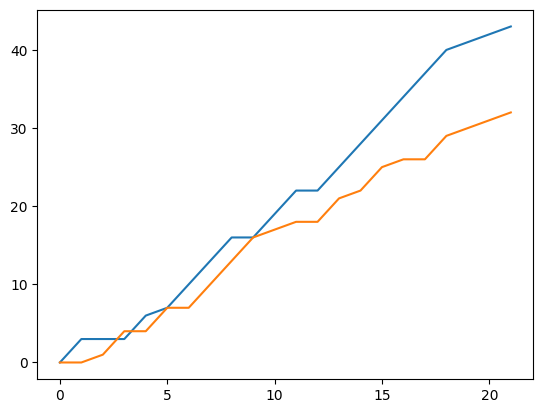

In [55]:
# Create a line plot with matchday and teamlist figures for two teams
plt.plot(match_day, team_lists["Man City"])
plt.plot(match_day, team_lists["Man United"])

## 5. Style the visualization

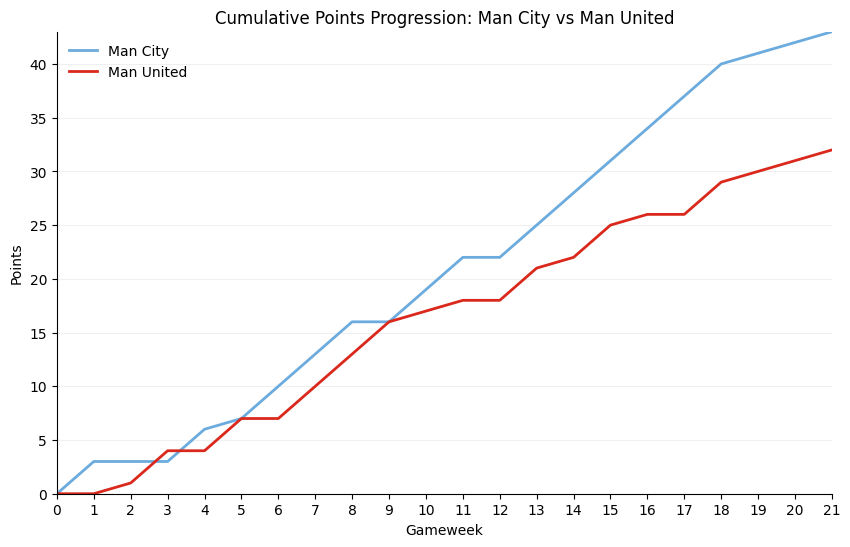

In [56]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot cumulative running totals
ax.plot(match_day, team_lists["Man City"], color="#6CABDD", linewidth=2, label="Man City")
ax.plot(match_day, team_lists["Man United"], color="#DA291C", linewidth=2, label="Man United")

# Axis labels and title
ax.set_xlabel("Gameweek")
ax.set_ylabel("Points")
ax.set_title("Cumulative Points Progression: Man City vs Man United")

# Force integer gameweek ticks (IMPORTANT FIX)
ax.set_xticks(match_day)

# Light grid for readability
ax.grid(True, axis="y", color="#F0F0F0")
ax.grid(False, axis="x")

# Remove unnecessary spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Remove margins
ax.margins(x=0, y=0)

# Add legend
ax.legend(frameon=False)

# Show plot
plt.show()
